In [1]:
import torch
import time
import warnings
import os
from tqdm import tqdm

from device import setup_device
from datasets.utk_dataset import UTKFaceDataset
from datasets.loading import get_full_loader
from model.encoder import Encoder
from model.loading import load_model
from loss import *
from train_encoder import *
from visualization import *
from utils.extraction import extract_embeddings

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

from numba.core.errors import NumbaWarning
warnings.filterwarnings("ignore", category=NumbaWarning)

warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")

In [3]:
verbose=True

In [4]:
device, data_parallel = setup_device(use_gpu_1_only=False, verbose=verbose)

[02:25:00] [INFO] ✅ CUDA is available: 2 GPU(s) visible


In [5]:
backbone_model = 'resnet50'
pretrained = True
model = Encoder(backbone_name=backbone_model, pretrained=pretrained)
model = data_parallel(model).to(device)

[02:25:01] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs


In [6]:
test_dir = './outputs/current/initial_test'
best_model_file = 'best_model.pth'

monitor_config = {
    'mode': 'max',
    'key_metric': 'kendall', #'train_loss',
    'base_dir': test_dir,
    'best_model_file': best_model_file,
    'save_analysis': True,
    'early_stopping': True,
    'patience': 10,
    'delta': 1e-4
}

config = {
    'device': device,
    'data_folder': './data/utkface/UTKFace',
    'model': model
}

train_config = {
    'batch_size': 256,
    'num_epochs': 2,
    'learning_rate': 1e-3,
    'temperature': 0.5,
    'augmentations': 'crop,flip,color,grayscale',
    'train_size': 0.8,
    'metrics': [
        "val_loss",
        "embedding_norm",
        "embedding_variance",
        "knn_accuracy",
        "spearman",
        "kendall",
        "grad_norm",
        "lr"
    ],
    'monitor_config': monitor_config
}

In [7]:
start_time = time.time()
train_encoder({**config, **train_config}, verbose=verbose)
end_time = time.time()
print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", verbose)

[02:25:01] [INFO] Configuration check passed: 10 keys found.
[02:25:01] [INFO] Training on device: cuda


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.35batch/s]


[02:26:05] [INFO] ✅ New best kendall: 0.4955 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.31batch/s]


[02:27:10] [INFO] 📝 TensorBoard writer closed.
[02:27:10] [INFO] Training complete!
[02:27:10] [INFO] Training completed in: 128.86 seconds


In [8]:
model = load_model(model, os.path.join(test_dir, best_model_file), verbose=verbose)
full_loader = get_full_loader('./data/utkface/UTKFace')

# Disable the projection layer
if hasattr(model, 'projector'):
    model.projector = nn.Identity()
        
embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)
print_verbose(f"Shape of embeddings: {tuple(embeddings.shape)}", verbose)
print_verbose(f"Memory usage of embeddings: {embeddings.nbytes / (1024 ** 2):.2f} MB", verbose) 

[02:27:10] [INFO] Loaded model from ./outputs/current/initial_test/best_model.pth, epoch 0, best loss: 5.0799


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.54batch/s]


[02:27:29] [INFO] Shape of embeddings: (23708, 128)
[02:27:29] [INFO] Memory usage of embeddings: 11.58 MB


In [9]:
checkpoint_dir = os.path.join(test_dir, 'analysis')
checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.startswith("epoch_") and f.endswith(".pt")]
)

embeddings_list = []
labels_list = []

full_loader = get_full_loader('./data/utkface/UTKFace')

for ckpt_file in checkpoint_files:
    model_path = os.path.join(checkpoint_dir, ckpt_file)
    
    # Load model from checkpoint
    model = load_model(model, model_path, verbose=verbose)
    model.to(device)
    model.eval()

    # Disable the projection layer if present
    if hasattr(model, 'projector'):
        model.projector = nn.Identity()

    # Extract embeddings and labels        
    embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)

    # Append
    embeddings_list.append(embeddings)
    labels_list.append(labels)

[02:27:29] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_000.pt, epoch 0, best loss: 5.0799


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.25batch/s]


[02:27:48] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_001.pt, epoch 1, best loss: 4.9781


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.57batch/s]


[02:28:07] [INFO] [visualize] Running: umap
[02:28:29] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


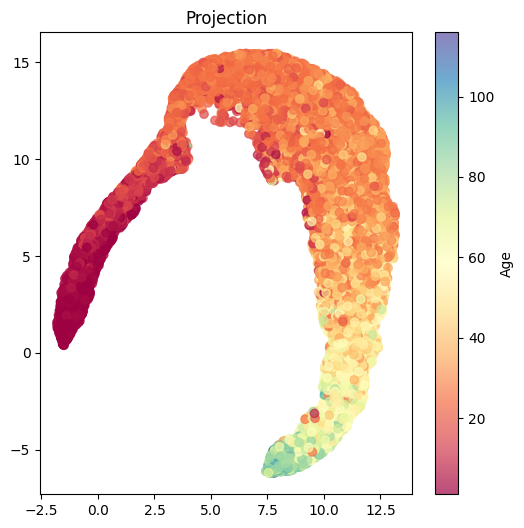

[02:28:29] [INFO] [visualize] Running: similarity_matrix
[02:28:29] [INFO] [plot_similarity_matrix] embeddings: torch.Size([1500, 128]), labels: torch.Size([1500])


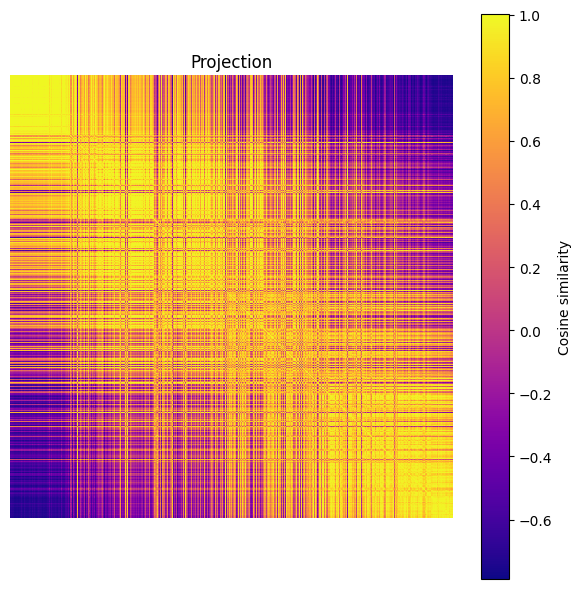

[02:28:30] [INFO] [visualize] Running: umap_all
[02:28:38] [INFO] [plot_umap_all_epochs_grid] Epoch 0: torch.Size([23708, 128]), torch.Size([23708])
[02:28:46] [INFO] [plot_umap_all_epochs_grid] Epoch 1: torch.Size([23708, 128]), torch.Size([23708])


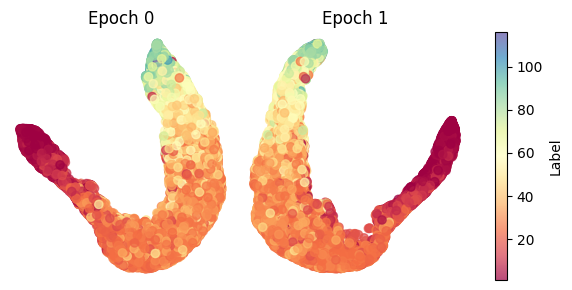

[02:28:46] [INFO] Visualization computed in: 38.98 seconds


In [10]:
selected = ['umap', 'similarity_matrix', 'umap_all']

args = {
    'embeddings': embeddings,
    'labels': labels,
    'figsize': (6, 6),
    'figssize': (3, 3),
    'n': 1500,
    'title': 'Projection',
    'embeddings_list': embeddings_list,
    'labels_list': labels_list
}

start_time = time.time()
visualize(selected, args, verbose=verbose)
end_time = time.time()

print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", verbose)